<a href="https://colab.research.google.com/github/lesterlnds/lesterlnds/blob/main/dataviz(pre).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
1!pip install openpyxl


In [ ]:
import pandas as pd

# Load the file
file_path = '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'

# Load the sheet (change the sheet name if needed)
df = pd.read_excel(file_path, sheet_name='DB', header=4)  # assuming headers start at row 4

# Display the first few rows
df.head()


,Region,Division,District,BEIS School ID,School Name,Street Address,Province,Municipality,Legislative District,Barangay,...,G12 ACAD GAS Male,G12 ACAD GAS Female,G12 ACAD PBM Male,G12 ACAD PBM Female,G12 TVL Male,G12 TVL Female,G12 SPORTS Male,G12 SPORTS Female,G12 ARTS Male,G12 ARTS Female
0,Region I,Ilocos Norte,Bacarra I,100001,Apaleng-Libtong ES,"Brgy. 21, Libtong, Bacarra, Ilocos Norte",ILOCOS NORTE,BACARRA,1st District,LIBTONG,...,0,0,0,0,0,0,0,0,0,0
1,Region I,Ilocos Norte,Bacarra I,100002,Bacarra CES,Santa Rita,ILOCOS NORTE,BACARRA,1st District,SANTA RITA (POB.),...,0,0,0,0,0,0,0,0,0,0
2,Region I,Ilocos Norte,Bacarra I,100003,Buyon ES,NONE,ILOCOS NORTE,BACARRA,1st District,BUYON,...,0,0,0,0,0,0,0,0,0,0
3,Region I,Ilocos Norte,Bacarra I,100004,Ganagan Elementary School,"#37 Ganagan,Bacarra, Ilocos Norte",ILOCOS NORTE,BACARRA,1st District,GANAGAN,...,0,0,0,0,0,0,0,0,0,0
4,Region I,Ilocos Norte,Bacarra I,100005,Macupit ES,Macupit,ILOCOS NORTE,BACARRA,1st District,MACUPIT,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
# 🧹 Step 3: Clean the Data

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Identify all grade-level male/female columns
grade_columns = [col for col in df.columns if ('Male' in col or 'Female' in col)]

# Fill missing values with 0 and convert to numeric
for col in grade_columns:
    df[col] = pd.to_numeric(df[col].fillna(0), errors='coerce')

# Create Total Enrollment column
df['Total_Enrollment'] = df[grade_columns].sum(axis=1)

print("\n✅ Data cleaning complete. Sample of cleaned data:")
print(df[['School Name', 'Region', 'Total_Enrollment']].head())


✅ Data cleaning complete. Sample of cleaned data:
                 School Name    Region  Total_Enrollment
0         Apaleng-Libtong ES  Region I                58
1                Bacarra CES  Region I               402
2                   Buyon ES  Region I               128
3  Ganagan Elementary School  Region I                91
4                 Macupit ES  Region I                53


<ipython-input-10-659d7a869983>:14: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Region', y='Primary_Gender_Ratio', data=df_top_regions, ci=None, palette='Blues')
<ipython-input-10-659d7a869983>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Region', y='Primary_Gender_Ratio', data=df_top_regions, ci=None, palette='Blues')


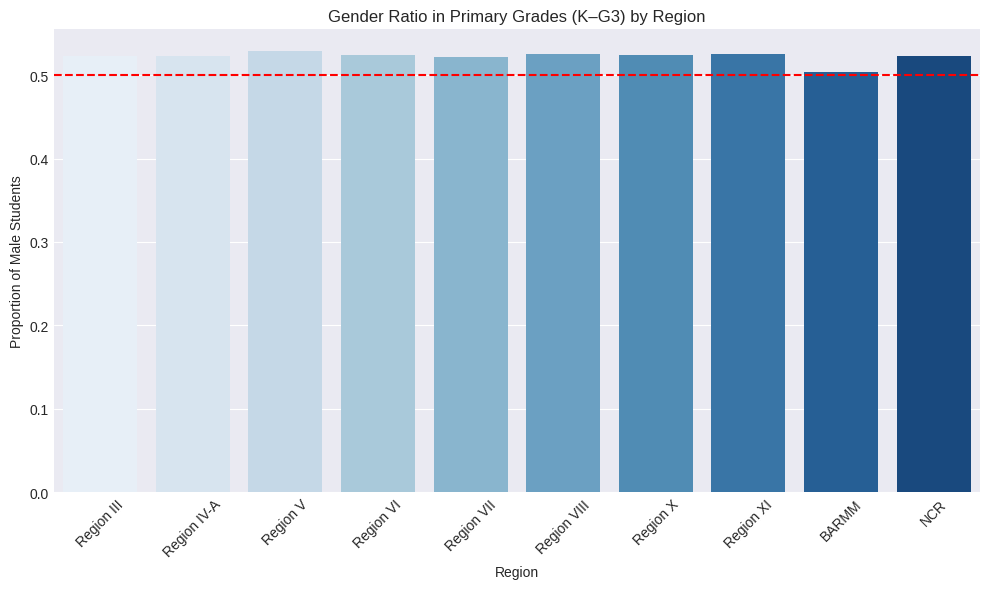

In [ ]:
# 📊 Visualization 2: Gender Ratio Imbalance in Primary Grades (K–G3)
primary_grades = ['K', 'G1', 'G2', 'G3']
male_cols = [f'{g} Male' for g in primary_grades]
female_cols = [f'{g} Female' for g in primary_grades]

df['Primary_Male'] = df[male_cols].sum(axis=1)
df['Primary_Female'] = df[female_cols].sum(axis=1)
df['Primary_Gender_Ratio'] = df['Primary_Male'] / (df['Primary_Male'] + df['Primary_Female'])

top_regions = df.groupby('Region')['Primary_Male'].sum().sort_values(ascending=False).head(10).index
df_top_regions = df[df['Region'].isin(top_regions)]

plt.figure(figsize=(10, 6))
sns.barplot(x='Region', y='Primary_Gender_Ratio', data=df_top_regions, ci=None, palette='Blues')
plt.axhline(0.5, color='red', linestyle='--')
plt.title("Gender Ratio in Primary Grades (K–G3) by Region")
plt.ylabel("Proportion of Male Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

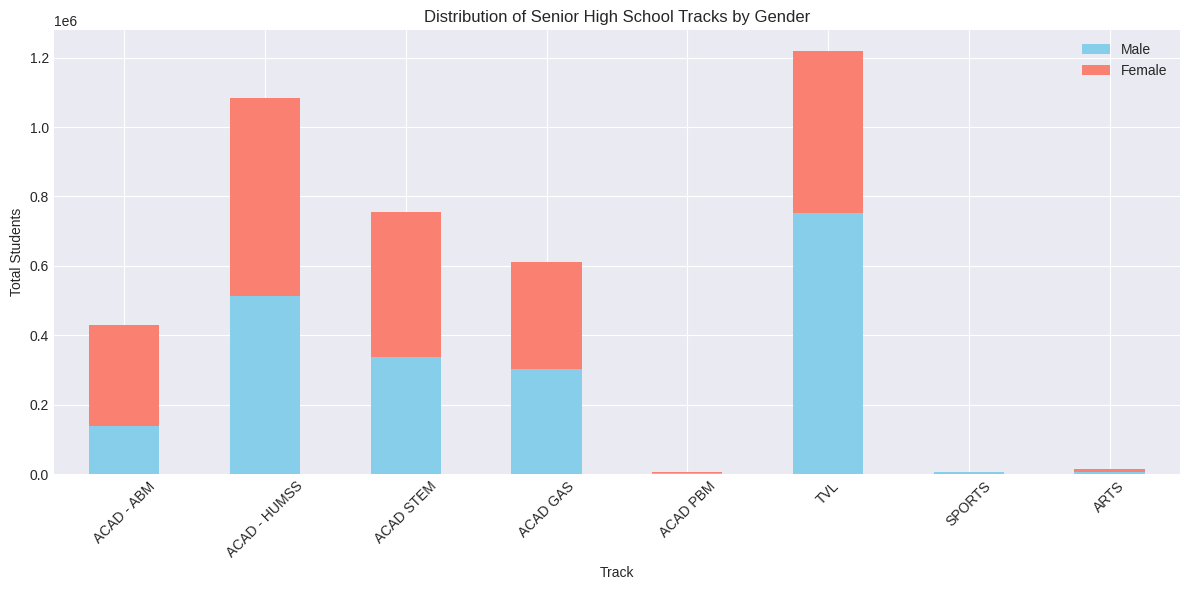

In [ ]:
# 📊 Visualization 4: Distribution of Senior High School Tracks
shs_tracks = [
    'ACAD - ABM', 'ACAD - HUMSS', 'ACAD STEM', 'ACAD GAS',
    'ACAD PBM', 'TVL', 'SPORTS', 'ARTS'
]

track_male = {track: df[[f"G11 {track} Male", f"G12 {track} Male"]].sum().sum() for track in shs_tracks}
track_female = {track: df[[f"G11 {track} Female", f"G12 {track} Female"]].sum().sum() for track in shs_tracks}

track_df = pd.DataFrame({
    'Track': shs_tracks,
    'Male': [track_male[t] for t in shs_tracks],
    'Female': [track_female[t] for t in shs_tracks]
})

track_df.set_index('Track').plot(kind='bar', stacked=True, figsize=(12, 6), color=['skyblue', 'salmon'])
plt.title("Distribution of Senior High School Tracks by Gender")
plt.ylabel("Total Students")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-13-4e0dec4b7e6d>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_per_region.index, y=missing_per_region.values, palette='coolwarm')


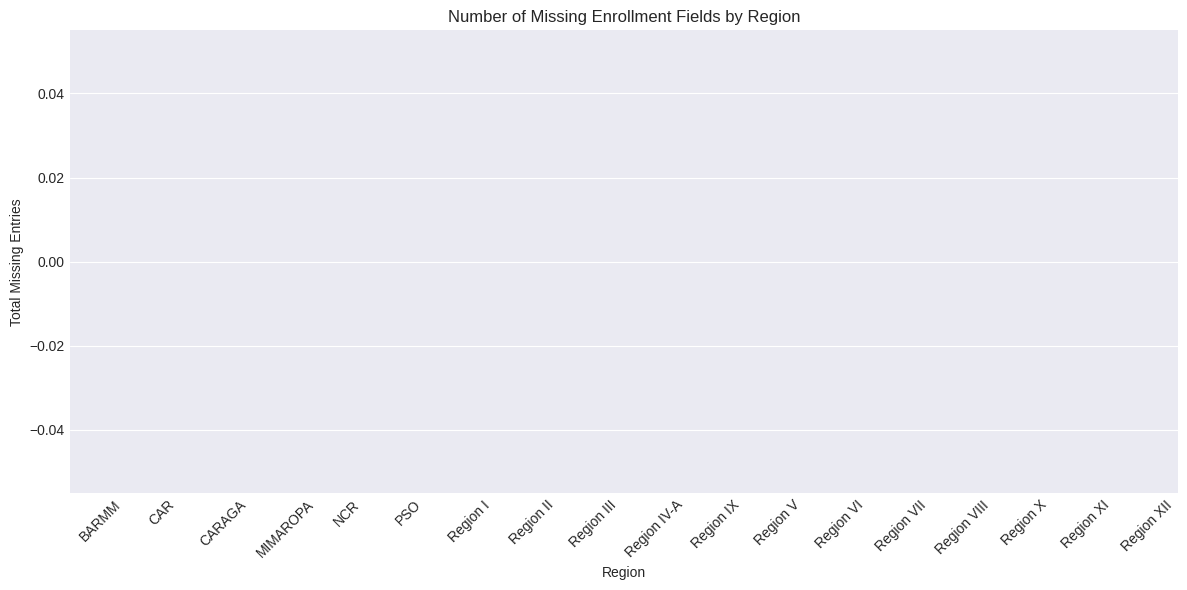

In [ ]:
# 📉 Visualization 5: Missing Enrollment by Region
missing_per_region = df.isnull()[grade_columns].groupby(df['Region']).sum().sum(axis=1)
missing_per_region = missing_per_region.sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_per_region.index, y=missing_per_region.values, palette='coolwarm')
plt.title("Number of Missing Enrollment Fields by Region")
plt.ylabel("Total Missing Entries")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

<ipython-input-14-8464cdc96ce2>:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


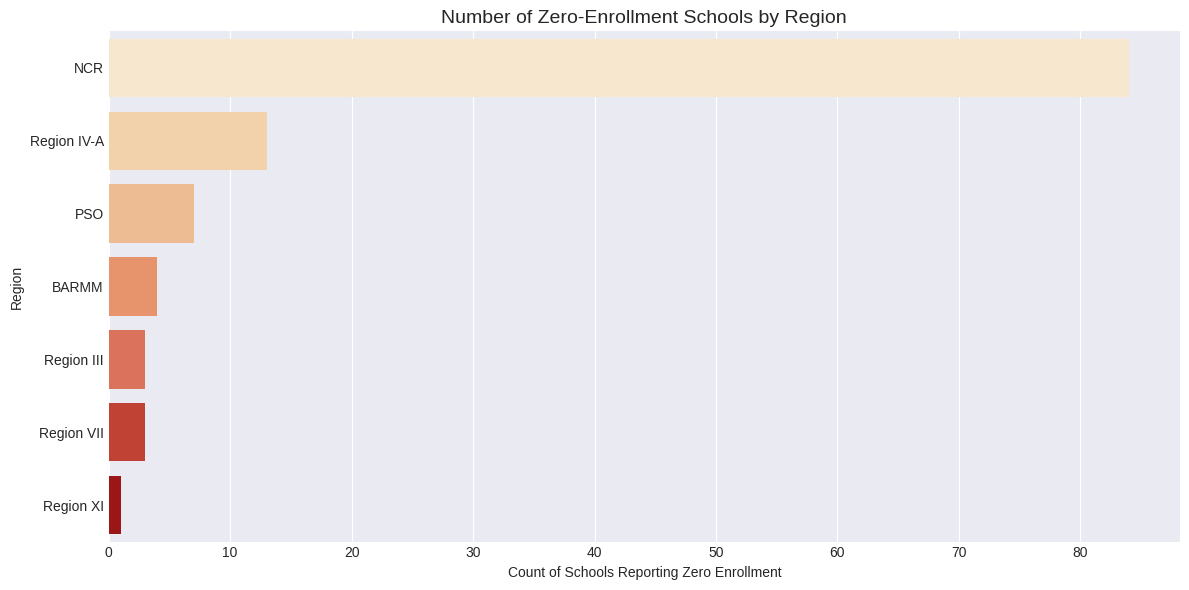


📋 List of Zero-Enrollment Schools with Geographic Details:
                                                                                 School Name                                                           Street Address                Barangay               Municipality                      Province      Region  Enrollment
                                                                St. Agnes Institute of Bagac                                                      #36 J.P.  Rizal St.      TABING-ILOG (POB.)                      BAGAC                        BATAAN  Region III           0
                              Hara and Hanah Montessori Academy of Angeles City Incorporated                           Friendship Hiway Barangay Cutcut, Angeles City                  CUTCUT               ANGELES CITY                      PAMPANGA  Region III           0
                                                   Benedictian School of Learning Foundation                  N. 49 LUCAS CHOA 

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📁 Step 1: Load your dataset from local file
file_path = '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'
df = pd.read_excel(file_path, sheet_name='DB', header=4)

# 🔍 Step 2: Identify all gender-based grade columns (e.g., K Male, G1 Female, etc.)
grade_columns = [col for col in df.columns if ('Male' in col or 'Female' in col)]

# 🧹 Step 3: Clean numeric data and calculate total enrollment per school
for col in grade_columns:
    df[col] = pd.to_numeric(df[col].fillna(0), errors='coerce')

df['Total_Enrollment'] = df[grade_columns].sum(axis=1)

# 🚫 Step 4: Filter schools with zero enrollment
zero_enrollment_df = df[df['Total_Enrollment'] == 0]

# 📍 Step 5: Count number of zero-enrollment schools per Region
zero_region_counts = zero_enrollment_df['Region'].value_counts().reset_index()
zero_region_counts.columns = ['Region', 'Zero_Enrollment_School_Count']

# 🎨 Step 6: Visualization - Bar Chart of Zero Enrollment by Region
plt.figure(figsize=(12, 6))
sns.barplot(
    data=zero_region_counts,
    x='Zero_Enrollment_School_Count',
    y='Region',
    palette='OrRd'
)
plt.title("Number of Zero-Enrollment Schools by Region", fontsize=14)
plt.xlabel("Count of Schools Reporting Zero Enrollment")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

# 📄 Step 7: Display Table of Zero-Enrollment Schools with Geographic Info
geo_columns = [
    'School Name', 'Street Address', 'Barangay', 'Municipality', 'Province', 'Region'
]
zero_geo_table = zero_enrollment_df[geo_columns].copy()
zero_geo_table['Enrollment'] = 0  # Add reference column

print("\n📋 List of Zero-Enrollment Schools with Geographic Details:")
print(zero_geo_table.to_string(index=False))

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
file_path = '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'
df = pd.read_excel(file_path, sheet_name='DB', header=4)

# Identify all gender-based grade columns (K–G12)
grade_columns = [col for col in df.columns if ('Male' in col or 'Female' in col)]

# Convert all numeric columns to float and calculate total enrollment per school
for col in grade_columns:
    df[col] = pd.to_numeric(df[col].fillna(0), errors='coerce')

df['Total_Enrollment'] = df[grade_columns].sum(axis=1)

# Group enrollment data by Region
region_enroll = df.groupby('Region')[grade_columns + ['Total_Enrollment']].sum()

# Replace zero values with NaN to highlight missing/low data
region_enroll_cleaned = region_enroll.replace(0, np.nan)

# --------------------------
# 1. 🔥 Heatmap: Total Enrollment by Region & Grade
# --------------------------
plt.figure(figsize=(16, 8))
sns.heatmap(region_enroll_cleaned[grade_columns].T, cmap="YlGnBu", annot=False, cbar=True)
plt.title("Heatmap of Total Enrollment by Region and Grade Level")
plt.xlabel("Region")
plt.ylabel("Grade")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------
# 2. 📈 Line Graph: Enrollment Trends Across Grades
# --------------------------
grade_levels = [col for col in grade_columns if 'Male' in col or 'Female' in col]
enrollment_by_grade = df[grade_columns].sum().sort_index()

plt.figure(figsize=(12, 6))
enrollment_by_grade.plot(kind='line', marker='o')
plt.title("Line Graph of Enrollment Trends Across Grades")
plt.xlabel("Grade and Gender")
plt.ylabel("Total Students")
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# --------------------------
# 3. 📊 Bar Chart: Gender Ratio by Grade
# --------------------------
male_columns = [col for col in grade_columns if 'Male' in col]
female_columns = [col for col in grade_columns if 'Female' in col]

total_male = df[male_columns].sum()
total_female = df[female_columns].sum()

grades = [col.split(' ')[0] for col in male_columns]
gender_ratio = total_male / (total_male + total_female)

plt.figure(figsize=(12, 6))
sns.barplot(x=grades, y=gender_ratio, palette="Blues")
plt.axhline(0.5, color='red', linestyle='--', label='Balanced Ratio')
plt.title("Gender Ratio by Grade (Proportion of Male Students)")
plt.xlabel("Grade")
plt.ylabel("Proportion of Male Students")
plt.legend()
plt.tight_layout()
plt.show()

# --------------------------
# 4. 📐 Histogram: Distribution of School-Level Enrollments
# --------------------------
plt.figure(figsize=(10, 6))
sns.histplot(df['Total_Enrollment'], bins=50, kde=True, color='teal')
plt.axvline(5, color='red', linestyle='--', label='Threshold for Abnormally Low Enrollment')
plt.title("Distribution of School-Level Total Enrollments")
plt.xlabel("Total Enrollment per School")
plt.ylabel("Number of Schools")
plt.legend()
plt.tight_layout()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'

<Figure size 1400x800 with 0 Axes>

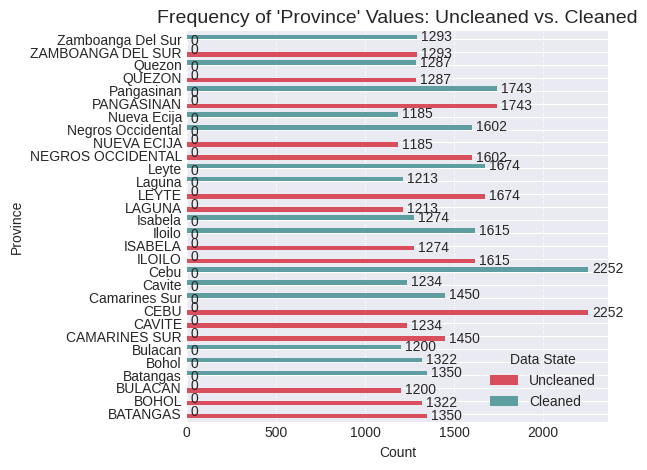

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
file_path = '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'
df = pd.read_excel(file_path, sheet_name='DB', header=4)

# Select a categorical column to clean (e.g., 'Province' or 'School Type')
column_to_clean = 'Province'

# Sample raw data
raw_data = df[column_to_clean]

# -----------------------------
# Step 1: Analyze Uncleaned Data
# -----------------------------
uncleaned_counts = raw_data.value_counts(dropna=False).head(15)

# -----------------------------
# Step 2: Clean the Data
# - Convert to title case
# - Strip extra spaces
# - Normalize common variants (optional, customize as needed)
# -----------------------------

# Define mapping for known inconsistent entries
province_mapping = {
    'MANDALUYONG CITY': 'Mandaluyong City',
    'mandaluyong city': 'Mandaluyong City',
    'QUEZON CITY': 'Quezon City',
    'quezon city': 'Quezon City',
    'CITY OF MANILA': 'Manila',
    'manila': 'Manila',
    # Add more mappings here based on your dataset
}

# Apply cleaning steps
cleaned_data = raw_data.str.strip().str.title()
cleaned_data = cleaned_data.replace(province_mapping)

# Update df with cleaned column
df[column_to_clean + '_Cleaned'] = cleaned_data

# Count cleaned values
cleaned_counts = cleaned_data.value_counts(dropna=False).head(15)

# -----------------------------
# Step 3: Plot Side-by-Side Comparison
# -----------------------------
# Combine into one DataFrame for plotting
combined = pd.DataFrame({
    'Uncleaned': uncleaned_counts,
    'Cleaned': cleaned_counts
})

# Plot
plt.figure(figsize=(14, 8))
ax = combined.plot(kind='barh', color=['#d94e5d', '#5f9ea0'], width=0.7)
plt.title(f"Frequency of '{column_to_clean}' Values: Uncleaned vs. Cleaned", fontsize=14)
plt.xlabel("Count")
plt.ylabel(column_to_clean)
plt.legend(title="Data State")
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Annotate bars for clarity
for container in ax.containers:
    ax.bar_label(container, label_type='edge', padding=3, fontsize=10)

plt.tight_layout()
plt.show()

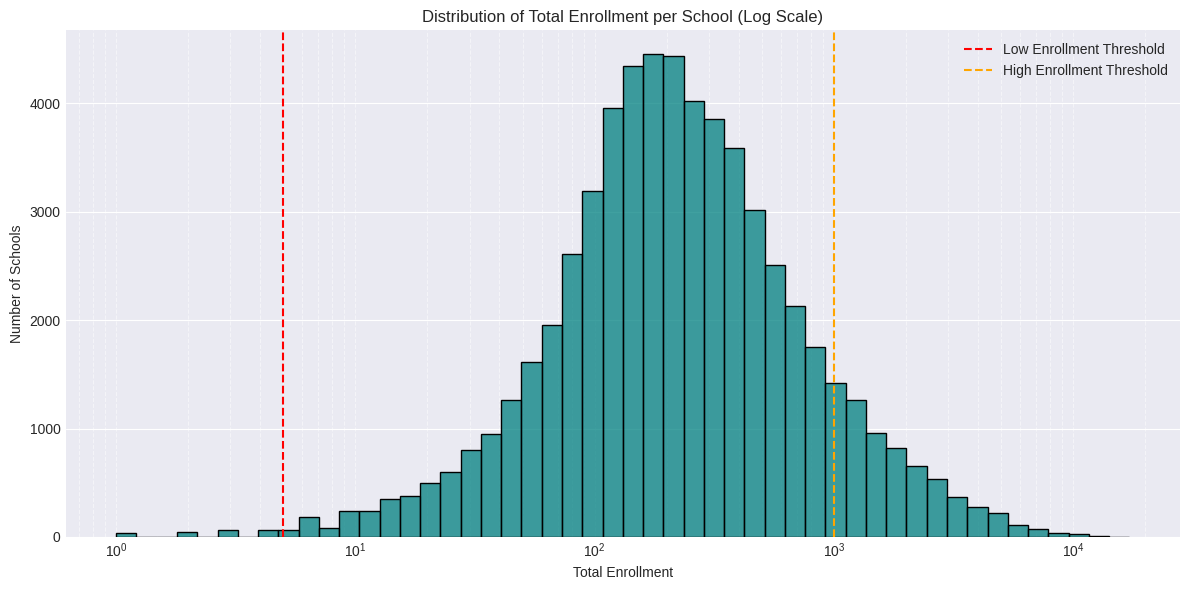

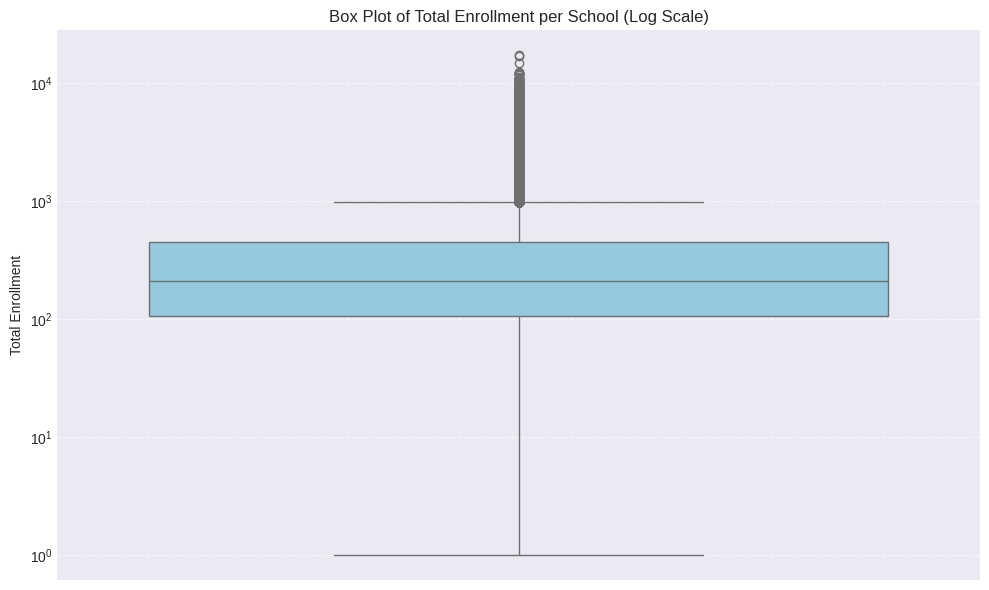

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load your dataset
file_path = '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'
df = pd.read_excel(file_path, sheet_name='DB', header=4)

# Identify all gender-based grade columns (K–G12)
grade_columns = [col for col in df.columns if ('Male' in col or 'Female' in col)]

# Convert numeric columns and calculate total enrollment per school
for col in grade_columns:
    df[col] = pd.to_numeric(df[col].fillna(0), errors='coerce')

df['Total_Enrollment'] = df[grade_columns].sum(axis=1)

# Remove schools with zero enrollment (to avoid skewing log scale)
df_nonzero = df[df['Total_Enrollment'] > 0]

# -----------------------------
# 1. 📐 Histogram with Log Scale
# -----------------------------
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_nonzero,
    x='Total_Enrollment',
    bins=50,
    kde=False,
    color='teal',
    log_scale=True
)
plt.axvline(5, color='red', linestyle='--', label='Low Enrollment Threshold')
plt.axvline(1000, color='orange', linestyle='--', label='High Enrollment Threshold')
plt.title("Distribution of Total Enrollment per School (Log Scale)")
plt.xlabel("Total Enrollment")
plt.ylabel("Number of Schools")
plt.legend()
plt.grid(True, which="both", axis="x", linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# -----------------------------
# 2. 📦 Box Plot of Enrollment
# -----------------------------
plt.figure(figsize=(10, 6))
sns.boxplot(data=df_nonzero, y='Total_Enrollment', color='skyblue')
plt.yscale('log')
plt.title("Box Plot of Total Enrollment per School (Log Scale)")
plt.ylabel("Total Enrollment")
plt.grid(True, axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

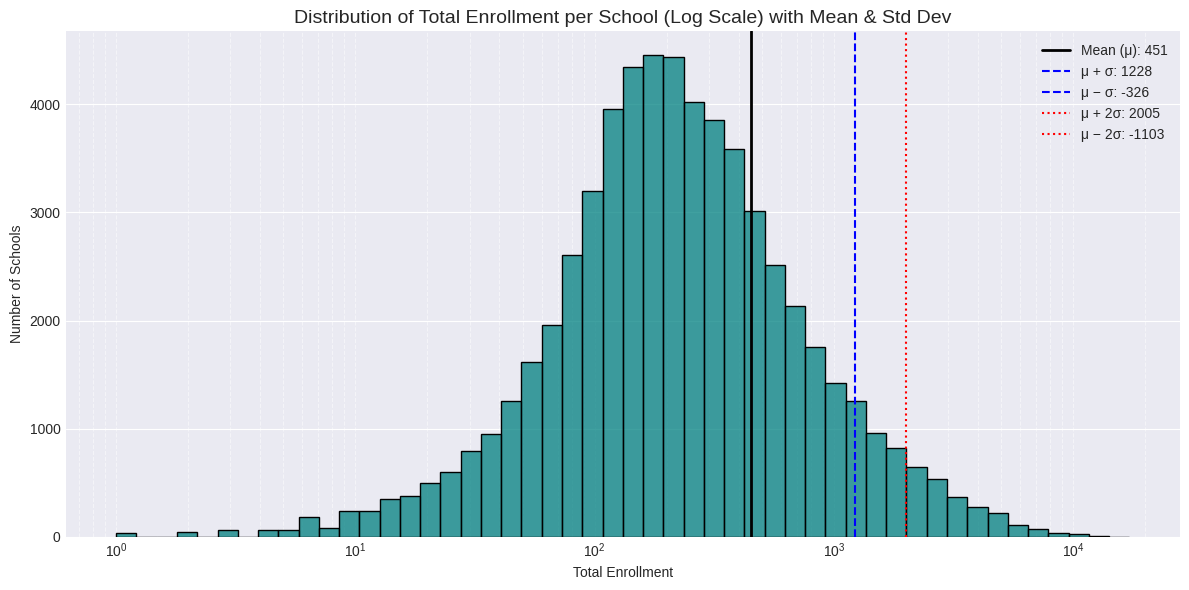

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'
df = pd.read_excel(file_path, sheet_name='DB', header=4)

# Identify all gender-based grade columns (K–G12)
grade_columns = [col for col in df.columns if ('Male' in col or 'Female' in col)]

# Convert numeric columns and calculate total enrollment per school
for col in grade_columns:
    df[col] = pd.to_numeric(df[col].fillna(0), errors='coerce')

df['Total_Enrollment'] = df[grade_columns].sum(axis=1)

# Remove schools with zero enrollment
df_nonzero = df[df['Total_Enrollment'] > 0]

# -----------------------------
# Calculate mean and standard deviation
# -----------------------------
enrollments = df_nonzero['Total_Enrollment']
mean = enrollments.mean()
std = enrollments.std()

one_sigma_low = mean - std
one_sigma_high = mean + std
two_sigma_low = mean - 2 * std
two_sigma_high = mean + 2 * std

# -----------------------------
# 📐 Histogram with Log Scale + Standard Deviation Lines
# -----------------------------
plt.figure(figsize=(12, 6))
sns.histplot(
    data=df_nonzero,
    x='Total_Enrollment',
    bins=50,
    kde=False,
    color='teal',
    log_scale=True
)

# Add vertical lines for mean and standard deviations
plt.axvline(mean, color='black', linestyle='-', linewidth=2, label=f'Mean (μ): {mean:.0f}')
plt.axvline(one_sigma_high, color='blue', linestyle='--', linewidth=1.5, label=f'μ + σ: {one_sigma_high:.0f}')
plt.axvline(one_sigma_low, color='blue', linestyle='--', linewidth=1.5, label=f'μ − σ: {one_sigma_low:.0f}')
plt.axvline(two_sigma_high, color='red', linestyle=':', linewidth=1.5, label=f'μ + 2σ: {two_sigma_high:.0f}')
plt.axvline(two_sigma_low, color='red', linestyle=':', linewidth=1.5, label=f'μ − 2σ: {two_sigma_low:.0f}')

# Labels and layout
plt.title("Distribution of Total Enrollment per School (Log Scale) with Mean & Std Dev", fontsize=14)
plt.xlabel("Total Enrollment")
plt.ylabel("Number of Schools")
plt.legend()
plt.grid(True, which="both", axis="x", linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

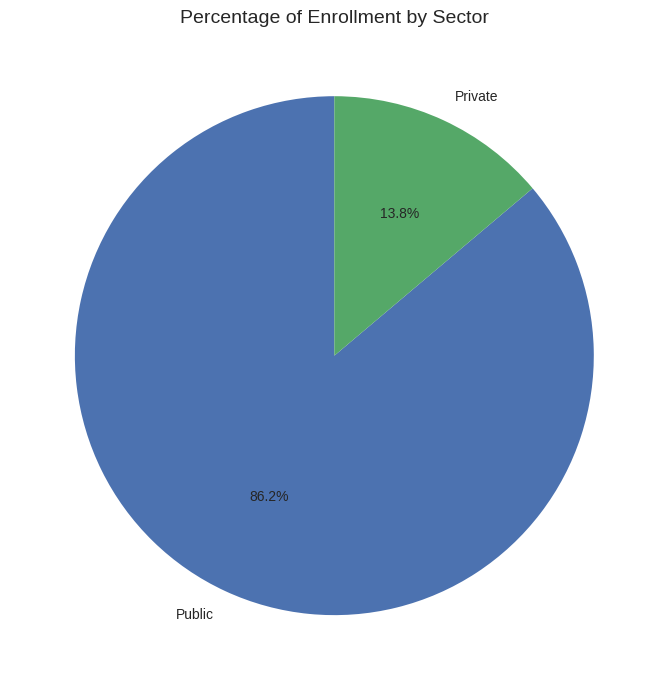

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
file_path = '/content/Copy of SY 2023-2024 School Level Data on Official Enrollment 13.xlsx'
df = pd.read_excel(file_path, sheet_name='DB', header=4)

# Identify all gender-based grade columns (K–G12)
grade_columns = [col for col in df.columns if ('Male' in col or 'Female' in col)]

# Convert numeric columns and calculate total enrollment per school
for col in grade_columns:
    df[col] = pd.to_numeric(df[col].fillna(0), errors='coerce')

df['Total_Enrollment'] = df[grade_columns].sum(axis=1)

# -----------------------------
# Filter rows with valid 'Sector' values
# Adjust column name if needed — e.g., 'School Sector' or 'Ownership'
sector_column = 'Sector'
valid_sectors = ['Public', 'Private']

df_sector = df[df[sector_column].isin(valid_sectors)].copy()

# Group enrollment by sector
sector_enroll = df_sector.groupby(sector_column)['Total_Enrollment'].sum().sort_values(ascending=False)


# -----------------------------
# Optional: Pie Chart – Percentage Distribution
# -----------------------------
plt.figure(figsize=(7, 7))
sector_enroll.plot(kind='pie', autopct='%1.1f%%', colors=['#4C72B0', '#55A868'], startangle=90)
plt.title("Percentage of Enrollment by Sector", fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()